# 02 — Detect incoherence (breakdowns and reversions)

**Goal:** for every monitored relationship, decide each day whether it is
behaving NORMALLY or is BROKEN, log every state change to SQLite, and
plot what happened.

### The idea, step by step

1. **Turn levels into daily moves.** Correlation of *levels* is misleading
   (two trending series always look correlated). We correlate *daily moves*:
   % change for prices/FX, point change for yields/spreads/VIX.

2. **Two rolling correlations of those moves:**
   - `corr_long` — 252-day (≈1 year) window = what the relationship
     *normally* looks like.
   - `corr_short` — 21-day (≈1 month) window = what it looks like
     *right now*.

3. **A baseline sign.** For most pairs we know the sign it "should" have
   (SPX vs VIX should be negative). For regime pairs (rates vs equity)
   we use the sign of `corr_long` as the baseline — i.e. "whatever the
   last year looked like".

4. **Breakdown rule.** Multiply `corr_short` by the baseline sign so that
   "healthy" is always a positive number. If that signed number drops
   below **-0.15 for 3 days in a row**, the relationship has flipped:
   that is a *breakdown*. (Your example: equity down + credit tightening
   flips the SPX-vs-spread correlation from negative to positive.)

5. **Reversion rule.** Once broken, if the signed number climbs back above
   **+0.15 for 3 days in a row**, log a *reversion* — the old logic is back.

The 3-day confirmation stops one noisy day from spamming the database.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import db
from pairs_config import PAIRS

# --- tuning knobs (change these and re-run to be more/less sensitive) ---
LONG_WINDOW = 252     # days for the "normal" correlation
SHORT_WINDOW = 21     # days for the "current" correlation
FLIP_LEVEL = 0.15     # how far past zero the signed short corr must go
CONFIRM_DAYS = 3      # consecutive days required to confirm a state change
MIN_LONG_CORR = 0.20  # ignore pairs whose long-run link is weaker than this

prices = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
print(f"Loaded {len(prices)} rows of prices")

Loaded 784 rows of prices


### Step 1+2: moves and rolling correlations

`to_moves` applies the right transform per ticker. Then `pandas` does the
rolling correlation for us: `a.rolling(window).corr(b)` computes the
correlation over a sliding window ending on each date.

In [2]:
def to_moves(series, transform):
    """Turn a level series into daily moves."""
    if transform == "pct":
        return series.pct_change()   # (today / yesterday) - 1
    return series.diff()             # today - yesterday  (for yields/spreads)


def pair_correlations(pair):
    """Return a DataFrame with corr_short and corr_long for one pair."""
    moves_a = to_moves(prices[pair["ticker_a"]], pair["transform_a"])
    moves_b = to_moves(prices[pair["ticker_b"]], pair["transform_b"])
    out = pd.DataFrame({
        "corr_short": moves_a.rolling(SHORT_WINDOW).corr(moves_b),
        "corr_long":  moves_a.rolling(LONG_WINDOW).corr(moves_b),
    })
    return out.dropna()


# quick look at one pair to make sure it behaves
example = pair_correlations(PAIRS[0])
print(PAIRS[0]["name"])
print(example.tail(3).round(3))

Equity vs CDX HY
            corr_short  corr_long
2026-07-07      -0.637     -0.388
2026-07-08      -0.688     -0.395
2026-07-09      -0.694     -0.396


### Step 3+4+5: the state machine

We walk forward through time keeping a `state` ("NORMAL" or "BROKEN")
and a counter of how many days in a row the flip condition has held.
Every confirmed change becomes one row in the `events` table.

This is a plain `for` loop on purpose — easy to read, easy to debug,
and 8 pairs x ~750 days is nothing for a loop.

In [3]:
def detect_events(pair, corrs):
    """Run the state machine for one pair. Returns (events, final_state)."""
    base = pair["expected_sign"]
    state = "NORMAL"
    breakdown_count = 0
    reversion_count = 0
    events = []

    for date, row in corrs.iterrows():
        # baseline sign: fixed if we have a prior, else follow the long corr
        sign = base if base != 0 else np.sign(row["corr_long"])

        # skip days where the relationship is too weak to mean anything
        if abs(row["corr_long"]) < MIN_LONG_CORR:
            breakdown_count = reversion_count = 0
            continue

        signed_short = row["corr_short"] * sign  # healthy => positive

        if state == "NORMAL":
            breakdown_count = breakdown_count + 1 if signed_short < -FLIP_LEVEL else 0
            if breakdown_count >= CONFIRM_DAYS:
                state = "BROKEN"
                breakdown_count = 0
                events.append(("breakdown", date, row["corr_short"], row["corr_long"]))
        else:  # BROKEN
            reversion_count = reversion_count + 1 if signed_short > FLIP_LEVEL else 0
            if reversion_count >= CONFIRM_DAYS:
                state = "NORMAL"
                reversion_count = 0
                events.append(("reversion", date, row["corr_short"], row["corr_long"]))

    return events, state

### Run every pair and save to SQLite

`db.py` creates `incoherence.db` next to these notebooks. Events are
INSERT OR IGNOREd, so re-running never duplicates rows — you can run
this notebook every day.

In [4]:
conn = db.get_connection()
all_corrs = {}  # keep for plotting below

for pair in PAIRS:
    corrs = pair_correlations(pair)
    all_corrs[pair["name"]] = corrs

    events, final_state = detect_events(pair, corrs)
    for event_type, date, c_short, c_long in events:
        db.insert_event(conn, pair["name"], event_type, date,
                        round(c_short, 3), round(c_long, 3),
                        note=pair["description"])

    last = corrs.iloc[-1]
    db.upsert_status(conn, pair["name"], final_state, corrs.index[-1],
                     round(last["corr_short"], 3), round(last["corr_long"], 3))

    print(f"{pair['name']:<28} state={final_state:<7} events found: {len(events)}")

Equity vs CDX HY             state=NORMAL  events found: 2


Equity vs CDX IG             state=NORMAL  events found: 2


Equity vs HY cash OAS        state=NORMAL  events found: 2
EU equity vs Crossover       state=NORMAL  events found: 2


Equity vs VIX                state=NORMAL  events found: 2


Rates vol vs Equity vol      state=NORMAL  events found: 0


...

Oil vs USDCAD                state=NORMAL  events found: 0


Oil vs 10y breakevens        state=NORMAL  events found: 0


Copper vs AUDUSD             state=NORMAL  events found: 0
Gold vs 10y real yield       state=NORMAL  events found: 0
Gold vs Silver               state=NORMAL  events found: 2


EM equity vs Dollar          state=BROKEN  events found: 1


Risk FX vs Equity            state=NORMAL  events found: 0


### What is in the database now?

In [5]:
events_df = pd.read_sql("SELECT * FROM events ORDER BY event_date", conn)
print(events_df[["pair_name", "event_type", "event_date",
                 "corr_short", "corr_long"]].to_string(index=False))

             pair_name event_type event_date  corr_short  corr_long
   EM equity vs Dollar  breakdown 2024-06-28       0.514      0.335
      Equity vs CDX HY  breakdown 2026-02-09       0.479     -0.716
      Equity vs CDX IG  breakdown 2026-02-09       0.461     -0.698
 Equity vs HY cash OAS  breakdown 2026-02-09       0.479     -0.695
         Equity vs VIX  breakdown 2026-02-09       0.430     -0.714
EU equity vs Crossover  breakdown 2026-02-10       0.412     -0.662
        Gold vs Silver  breakdown 2026-03-24      -0.263      0.282
        Gold vs Silver  reversion 2026-04-24       0.243      0.288
EU equity vs Crossover  reversion 2026-05-13      -0.323     -0.376
      Equity vs CDX HY  reversion 2026-05-14      -0.466     -0.420
      Equity vs CDX IG  reversion 2026-05-14      -0.491     -0.434
 Equity vs HY cash OAS  reversion 2026-05-14      -0.400     -0.405
         Equity vs VIX  reversion 2026-05-15      -0.451     -0.456


### Picture one breakdown

For the pair with the most events, plot the short vs long correlation.
A breakdown is where the blue line (1-month) crosses to the *wrong side*
of zero while the grey line (1-year) shows what normal looks like.

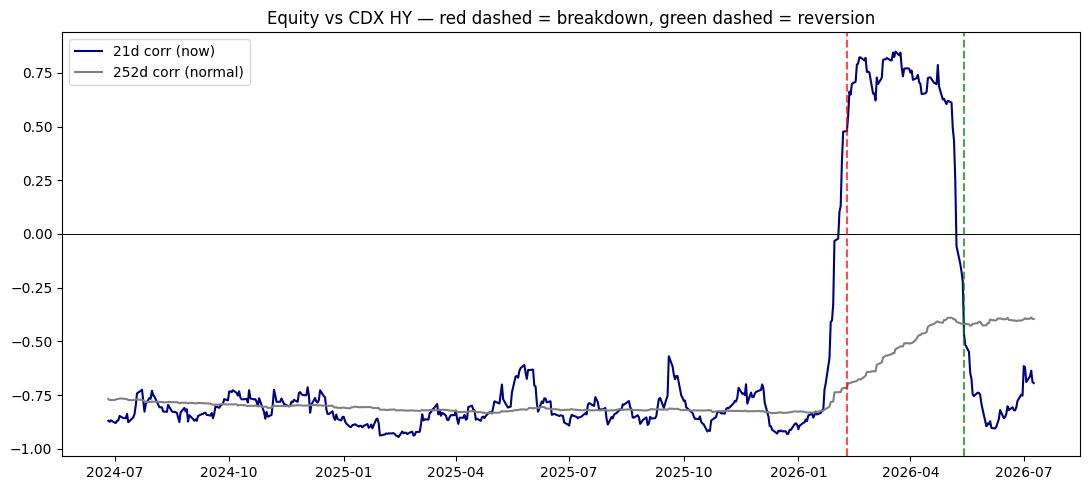

In [6]:
if len(events_df) > 0:
    busiest = events_df["pair_name"].value_counts().index[0]
    corrs = all_corrs[busiest]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(corrs.index, corrs["corr_short"], color="navy", label="21d corr (now)")
    ax.plot(corrs.index, corrs["corr_long"], color="grey", label="252d corr (normal)")
    ax.axhline(0, color="black", linewidth=0.7)

    for _, ev in events_df[events_df["pair_name"] == busiest].iterrows():
        color = "red" if ev["event_type"] == "breakdown" else "green"
        ax.axvline(pd.Timestamp(ev["event_date"]), color=color,
                   linestyle="--", alpha=0.7)

    ax.set_title(f"{busiest} — red dashed = breakdown, green dashed = reversion")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No events found — markets are behaving (or thresholds too strict).")

### Tuning cheat-sheet

- More alerts -> lower `FLIP_LEVEL` (e.g. 0.10) or `CONFIRM_DAYS` (e.g. 2)
- Fewer alerts -> raise them
- Catch slower drifts -> raise `SHORT_WINDOW` to 42 (2 months)
- The `MIN_LONG_CORR` filter stops noise pairs from alerting at all